<a href="https://colab.research.google.com/github/Plumz17/PP_FinalProject2/blob/main/PP_FinalProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pattern Recognition Project - Banana Variety and Ripeness Classification using Traditional ML Feature Extraction Methods
Arranged by:
*   Anders Emmanuel Tan (24/541351/PA/22964)
*   Danar Fathurahman (24/538200/PA/22828)

Description: Pada projek ini, kami akan menyusun pipeline lengkap menggunakan teknik-teknik ekstraksi fitur tradisional untuk mengklasifikasi jenis dan tingkat kematangan pisang di Indonesia.

## 0. Image Acquisition (Loading the Dataset)
Description:

In [83]:
#Reset Runtime file
!rm -rf *

In [84]:
# Import Important Libraries
import requests, os, zipfile, io, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [85]:
# Import Dataset
URL = "https://data.mendeley.com/public-api/zip/h6n5srjjyw/download/1"
os.makedirs("/content/banana", exist_ok=True)

r = requests.get(URL, stream=True, headers={"User-Agent": "Mozilla/5.0"})
total = int(r.headers.get("content-length", 0))

with open("/content/banana.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
  for chunk in r.iter_content(chunk_size=1024*1024):
    f.write(chunk)
    bar.update(len(chunk))

print("\n")
print("Download Complete!")

100%|██████████| 715M/715M [00:23<00:00, 30.1MB/s]



Download Complete!


In [86]:
# Extract outer zip
BASE_DIR = "/content/banana/BananaID An image dataset of banana varieties and/"
IMG_DIR  = "/content/banana_images"
with zipfile.ZipFile("/content/banana.zip") as z:
    z.extractall("/content/banana/")

# Extract all four inner zips
inner_zips = {
  "Banana Variety Dataset.zip":"variety_original",
  "Banana Ripeness Dataset.zip":"ripeness_original",
  "Augmented Banana Variety Dataset.zip":"variety_augmented",
  "Augmented Banana Ripeness Dataset.zip":"ripeness_augmented",
}

for zip_name, out_folder in inner_zips.items():
  zip_path = os.path.join(BASE_DIR, zip_name)
  out_path = os.path.join(IMG_DIR, out_folder)
  print(f"Extracting {zip_name}...")
  with zipfile.ZipFile(zip_path) as z:
    z.extractall(out_path)

print("Extraction complete!")

Extracting Banana Variety Dataset.zip...
Extracting Banana Ripeness Dataset.zip...
Extracting Augmented Banana Variety Dataset.zip...
Extracting Augmented Banana Ripeness Dataset.zip...
Extraction complete!


## 1. Preprocessing


In [87]:
#Variety Preprocessing
VARIETY_DIRS = [
  os.path.join(IMG_DIR, "variety_original/Banana Classification Dataset"),
  os.path.join(IMG_DIR, "variety_augmented/Augmented Banana Variety Dataset")
]

#Intialize array for images and labels
variety_images, variety_labels = [], []
#Name Banana's Variety class as their folder name
variety_class_names = sorted(os.listdir(VARIETY_DIRS[0]))
#Maps each class name with a number
variety_class_to_idx = {cls: idx for idx, cls in enumerate(variety_class_names)}

for dataset_dir in VARIETY_DIRS:
  for class_name in tqdm(variety_class_names, desc="Preprocessing Banana Variety..."):
    #Get Filepath to specific variety class path
    class_path = os.path.join(dataset_dir, class_name)
    for img_file in os.listdir(class_path):
      #Obtain image
      img = cv2.imread(os.path.join(class_path, img_file))
      if img is None:
        continue
      #Convert image to RGB for convinience sake
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      #Add image to image array
      variety_images.append(img)
      #Add label to label array
      variety_labels.append(variety_class_to_idx[class_name])

#Normalize and convert into a numpy array
variety_images = np.array(variety_images, dtype=np.uint8)
variety_labels = np.array(variety_labels)

print(f"Images : {variety_images.shape}")
print(f"Labels : {variety_labels.shape}")
print(f"Classes: {variety_class_names}")

Preprocessing Banana Variety...: 100%|██████████| 5/5 [00:15<00:00,  3.05s/it]


Images : (10710, 256, 384, 3)
Labels : (10710,)
Classes: ['Ambon', 'Cavendish', 'Mas', 'Raja', 'Saba']


In [88]:
#Ripeness Preprocessing
RIPENESS_DIRS = [
    os.path.join(IMG_DIR, "ripeness_original/Banana Ripeness Classification Dataset"),
    os.path.join(IMG_DIR, "ripeness_augmented/Augmented Banana Ripeness Classification Dataset")
]

#Intialize array for images and labels
ripeness_images, ripeness_labels = [], []

#Name Banana's Ripeness class as their folder name
ripeness_class_names = sorted(os.listdir(RIPENESS_DIRS[0]))
#Maps each class name with a number
ripeness_class_to_idx = {cls: idx for idx, cls in enumerate(ripeness_class_names)}

for dataset_dir in RIPENESS_DIRS:
  for class_name in tqdm(ripeness_class_names, desc="Preprocessing Banana Ripeness..."):
    #Get Filepath to specific ripeness class path
    class_path = os.path.join(dataset_dir, class_name)
    for img_file in os.listdir(class_path):
      #Obtain image
      img = cv2.imread(os.path.join(class_path, img_file))
      if img is None:
        continue
      #Convert image to RGB for convinience sake
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      #Add image to image array
      ripeness_images.append(img)
      #Add label to label array
      ripeness_labels.append(ripeness_class_to_idx[class_name])

#Normalize and convert into a numpy array
ripeness_images = np.array(ripeness_images, dtype=np.uint8)
ripeness_labels = np.array(ripeness_labels)

print(f"Images : {ripeness_images.shape}")
print(f"Labels : {ripeness_labels.shape}")
print(f"Classes: {ripeness_class_names}")

Preprocessing Banana Ripeness...: 100%|██████████| 4/4 [00:11<00:00,  2.88s/it]


Images : (8960, 256, 384, 3)
Labels : (8960,)
Classes: ['Half_Ripe', 'Overripe', 'Ripe', 'Unripe']


In [89]:
def show(before, after=None, title2= "Processed"): # Helper function to check the before and after of the processing
  plt.figure(figsize=(10,5))

  # Show original
  plt.subplot(1,2,1)
  plt.imshow(before, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")

  # Show processed
  if after is not None:
    plt.subplot(1,2,2)
    plt.imshow(after, cmap='gray', vmin=0, vmax=255)
    plt.title(title2)
    plt.axis("off")

  plt.show()

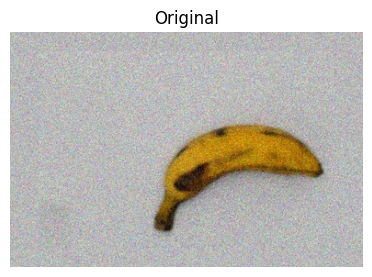

np.int64(0)

In [101]:
show(ripeness_images[1961])
ripeness_labels[1961]

## 2. Image Enhancement

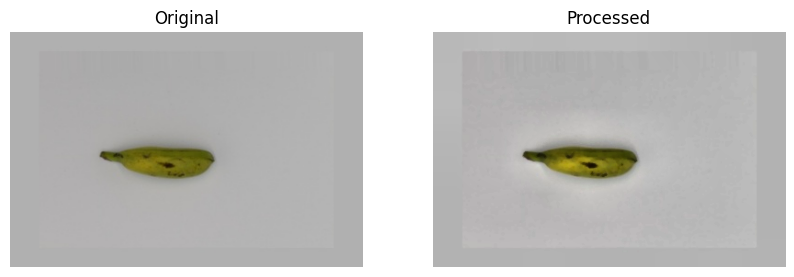

In [100]:
def image_enhancement(img):
  # 1. Convert to HSV
  hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

  # 2. Split channels
  h, s, v = cv2.split(hsv)

  # 3. Median Blur
  v_enhanced = cv2.medianBlur(v, 3)

  # 4. Apply CLAHE to V channel (brightness)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  v_enhanced = clahe.apply(v_enhanced)

  # 5. Merge back
  hsv_enhanced = cv2.merge([h, s, v_enhanced])

  # 6. Convert back to BGR (for visualization / further processing)
  enhanced_img = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

  return enhanced_img


show(ripeness_images[1959], image_enhancement(ripeness_images[1959]))